# Assignment 9 - Jonas Gstöttenmayr

In [1]:
from pathlib import Path
from pydantic import BaseModel, Field, TypeAdapter


## Exercise 1 LLM Vision Models: Invoice Information Extraction with Ollama

In this exercise, you will work with multimodal Large Language Models (LLMs) to extract structured information from invoice images. You will use Ollama with the gemma4: e4b model to perform visual understanding and text extraction. The goal is to compare model-generated outputs with ground truth labels.

Tasks:
1. Load the provided invoice image dataset and corresponding labels from the e-learning platform.
2. Preprocess the data as needed (e.g., image loading, formatting prompts).
3. Design an effective prompt to extract relevant invoice information (e.g., company name, date, total amount, invoice number).
4. Use Ollama with the gemma4: e4b model to process the images and generate structured outputs.
5. Compare the extracted information with the provided labels:
    * Define suitable evaluation criteria (e.g., exact match, string similarity).
    * Compute basic performance metrics.
6. Analyze typical errors and discuss possible improvements (prompting, preprocessing, postprocessing).

Deliverables: A notebook containing the data loading process, prompts used, model outputs, evaluation results, and a short error analysis.

From the model README
4. Modality order

    For optimal performance with multimodal inputs, place image and/or audio content before the text in your prompt.


In [ ]:
import base64
import re
import json
from attr import dataclass
from typing import Any

import pandas as pd

from pydantic import BaseModel, Field, TypeAdapter
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama

In [3]:
DATA = Path("/home/azureuser/localfiles/jonas_g/NLP4/EX09/data/Sroie_dataset_100")

In [4]:
# 1. Define your output structure
class Receipt(BaseModel):
    """Extracted text fields from the image."""
    company: str = Field(description="The name of the company issuing the receipt.")
    date: str = Field(description="The date the receipt is issued, in the format of the receipt")
    address: str = Field(description="The address of the store which issued the recreceiptipt")
    total: float = Field(description="The total of the recipt, without a mention of currency")

In [5]:
@dataclass
class DataPoint:
    receipt: Receipt
    path: Path
    base64: str

In [6]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# this function is AI generated, prompt:
#  python regex i have a line which may or may not contain a short string
#  of currency type like eur and the currency, 
#  i wanto to just extract the amount. e.g. input "RM 10.20" 
def extract_amount(text):
    # Regex breakdown:
    # \d+        : One or more digits (the whole number part)
    # (?:\.\d+)? : An optional group matching a decimal point followed by digits
    match = re.search(r'\d+(?:\.\d+)?', text)
    return float(match.group(0) if match else 0.0)

In [7]:
samples:list[DataPoint] = []
files = [*(DATA/"images").iterdir()]
for image in files:
    lable = Path(str(image).replace("/images/", "/labels/").replace(".jpg", ".txt"))
    with open(lable, "r", encoding="utf-8") as f:
        dic: dict[str, str] = json.JSONDecoder().decode(f.read())
        receipt = Receipt(
            company=dic["company"],
            date=dic["date"],
            address=dic["address"],
            total=extract_amount(dic["total"]))
    samples.append(
        DataPoint(
            receipt,
            str(image),
            encode_image(image)
        )
    )   

In [8]:
samples[0]

DataPoint(receipt=Receipt(company='SANYU STATIONERY SHOP', date='12/09/2017', address='NO. 31G&33G, JALAN SETIA INDAH X ,U13/X 40170 SETIA ALAM', total=8.7), path='/home/azureuser/localfiles/jonas_g/NLP4/EX09/data/Sroie_dataset_100/images/X51007339121.jpg', base64='...')

In [9]:
llm = ChatOllama(
    model="gemma4:e4b",
    temperature=0.0,
    top_p=0.95,
    top_k=64,
    streaming=False,
    verbose=True,
    reasoning=False,
    num_ctx = 4096*2,
    num_predict=1024
)
llm = llm.with_structured_output(Receipt, include_raw=True)

In [10]:
prompt = ChatPromptTemplate(
    [
        ("system", "You are an expert image analyzer, your input will be recipts. Your one job is to extract the company, date, address and total of the recipt."),
        ("user", [
            {"type": "text", "text": "Analyze this image and extract the required fields."},
            {"type": "image_url", "image_url": {"url": "data:image/jpeg;base64,{image_data}"}}
        ])
    ]
)
chain = prompt | llm

In [11]:
response = chain.invoke({"image_data": samples[2].base64})
print("Input (image) tokens", response["raw"].response_metadata["prompt_eval_count"])
response["parsed"]

Input (image) tokens 325


Receipt(company='OLD TOWN WHITE COFFEE', date='Jun 18', address='LOT NO 134, GIANT HYPERMARKET PLENTONG', total=28.0)

In [12]:
samples[2].path

'/home/azureuser/localfiles/jonas_g/NLP4/EX09/data/Sroie_dataset_100/images/X51007846358.jpg'

In [13]:
responses = []
responses_file = DATA.parent/"sroie_respones.json"
list_adapter = TypeAdapter(list[Receipt])
if responses_file.exists():
    print("loaded respones")
    responses = list_adapter.validate_json(responses_file.read_text().replace("null", """{"company": "","date": "","address":"","total": 0.0}"""))
else:
    highest_input_tokens = 0
    count = 0
    for sample in samples:
        if count %10 == 0:
            print(f"Processing the {count}th sample ...(*￣０￣)ノ")
        response = chain.invoke({"image_data": sample.base64})
        responses.append(response["parsed"] if response["parsed"] else Receipt(company="", date="", address="", total=0.0))
        if response["raw"].response_metadata["prompt_eval_count"] > highest_input_tokens:
            highest_input_tokens = int(response["raw"].response_metadata["prompt_eval_count"])
        count += 1
    print(highest_input_tokens)
    
    json_data = list_adapter.dump_json(responses)
    responses_file.write_bytes(json_data)

loaded respones


In [18]:
responses[46] == Receipt(company="", date="", address="", total=0.0)

True

In [49]:
def evaluate(whole_sample: DataPoint, response: Receipt):
    eval: dict[str, bool | float]= {}
    sample: Receipt = whole_sample.receipt
    eval["overall_is_none"] = response == Receipt(company="", date="", address="", total=0.0)
    eval["overall_exact_match"] = (sample == response)
    sd = sample.model_dump()
    rd = response.model_dump()
    # go over fields
    for key in sample.model_dump().keys():
        if key == "total":
            continue
        
        cs: str = sd[key]
        cr:str = rd[key]
        eval[f"{key}_exact_match"] = cs == cr
        
        same_chars = 0
        # count amount of same chars
        for i in range(min(len(cs), len(cr))):
            same_chars += int(cs[i] == cr[i])
        eval[f"{key}_charmatch"] = same_chars / max(len(cs), len(cr))
        
        # lowercase for more clossup
        cs = cs.lower()
        cr = cr.lower()
        eval[f"{key}_lower_exact_match"] = cs == cr
        
        same_chars = 0
        for i in range(min(len(cs), len(cr))):
            same_chars += int(cs[i] == cr[i])
        eval[f"{key}_lower_charmatch"] = same_chars / max(len(cs), len(cr))
        
        cs = "".join([c for c in cs if c.isalnum()])
        cr = "".join([c for c in cr if c.isalnum()])
        same_chars = 0
        for i in range(min(len(cs), len(cr))):
            same_chars += int(cs[i] == cr[i])
        eval[f"{key}_lower_pure_lettermatch"] = same_chars / max(len(cs), len(cr)) if max(len(cs), len(cr))>0 else 0
    
    eval["total_exact_match"] = sd["total"] == rd["total"]
    eval["total_abs_difference"] = abs(sd["total"] - rd["total"])
    eval["total_perc_difference"] = (1 - (rd["total"] / sd["total"] ) )if sd["total"] != 0 else 1

    return eval

In [50]:
evaluations = []
for sample, response in zip(samples, responses):
    evaluations.append(evaluate(sample, response))
df = pd.DataFrame(evaluations)
df

,overall_is_none,overall_exact_match,company_exact_match,company_charmatch,company_lower_exact_match,company_lower_charmatch,company_lower_pure_lettermatch,date_exact_match,date_charmatch,date_lower_exact_match,date_lower_charmatch,date_lower_pure_lettermatch,address_exact_match,address_charmatch,address_lower_exact_match,address_lower_charmatch,address_lower_pure_lettermatch,total_exact_match,total_abs_difference,total_perc_difference
0,False,False,True,1.0,True,1.0,1.0,True,1.000000,True,1.0,1.0,False,0.649123,False,0.649123,1.000000,True,0.00,0.000000
1,False,False,True,1.0,True,1.0,1.0,False,0.818182,True,1.0,1.0,False,0.666667,False,0.974359,1.000000,False,1.41,0.056627
2,False,False,False,0.0,False,0.0,0.0,False,0.000000,False,0.0,0.0,False,0.388235,False,0.388235,0.071429,True,0.00,0.000000
3,False,False,True,1.0,True,1.0,1.0,False,0.818182,True,1.0,1.0,False,0.157895,False,0.302632,1.000000,False,80.00,-9.039548
4,False,False,True,1.0,True,1.0,1.0,True,1.000000,True,1.0,1.0,False,0.232323,False,0.232323,0.866667,True,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,False,False,True,1.0,True,1.0,1.0,True,1.000000,True,1.0,1.0,False,0.649123,False,0.649123,1.000000,True,0.00,0.000000
96,False,False,False,0.0,False,0.0,0.1,True,1.000000,True,1.0,1.0,False,0.013333,False,0.040000,0.245614,True,0.00,0.000000
97,False,False,True,1.0,True,1.0,1.0,False,0.818182,True,1.0,1.0,False,0.171053,False,0.302632,0.983607,False,78.00,-8.914286
98,False,False,True,1.0,True,1.0,1.0,True,1.000000,True,1.0,1.0,False,0.435294,True,1.000000,1.000000,True,0.00,0.000000


In [51]:
print(f"{'='*25} OVERALL {'='*25}")
print("Null outputs by model: ", df["overall_is_none"].sum())
print("# Exact matches", df["overall_exact_match"].sum())
print(f"% Exact matches {df['overall_exact_match'].sum()/len(df)*100:.2f} %")
print(f"\n{'='*25} TOTAL {'='*25}")
print("# Exact matches", df["total_exact_match"].sum())
print(f"% Exact matches {df['total_exact_match'].sum()/len(df)*100:.2f} %")
print("Total absolute difference", df["total_abs_difference"].sum())
print("Total average difference", df["total_abs_difference"].mean())
print(f"Total average % difference {df['total_perc_difference'].mean()*100:.2f} %")

========================= OVERALL =========================
Null outputs by model:  1
# Exact matches 6
% Exact matches 6.00 %

========================= TOTAL =========================
# Exact matches 79
% Exact matches 79.00 %
Total absolute difference 527.12
Total average difference 5.2712
Total average % difference -42.23 %


In [52]:
print("charmatch is % of characters in same position")
print("lettermatchis % of alpha numeric characters (i.e. only letters and number) in correct position")
print()
# _exact_match	_charmatch	_lower_exact_match	_lower_charmatch	_lower_pure_lettermatch
for key in ["company", "date", "address"]:
    if key != "company":
        print()
    print(f"{'='*25} {key.upper()} {'='*25}")
    print("# Exact matches", df[f"{key}_exact_match"].sum())
    print(f"% Exact matches {df[f'{key}_exact_match'].sum()/len(df)*100:.2f} %")
    print(f"Average % char matches {df[f'{key}_charmatch'].mean()*100:.2f} %")
    print(f"Average % lower exact matches {df[f'{key}_lower_exact_match'].mean()*100:.2f} %")
    print(f"Average % lower charmatch {df[f'{key}_lower_charmatch'].mean()*100:.2f} %")
    print(f"Average % lower pure letter match {df[f'{key}_lower_pure_lettermatch'].mean()*100:.2f} %")
    

charmatch is % of characters in same position
lettermatchis % of alpha numeric characters (i.e. only letters and number) in correct position

========================= COMPANY =========================
# Exact matches 66
% Exact matches 66.00 %
Average % char matches 76.34 %
Average % lower exact matches 74.00 %
Average % lower charmatch 83.50 %
Average % lower pure letter match 84.99 %

========================= DATE =========================
# Exact matches 72
% Exact matches 72.00 %
Average % char matches 92.70 %
Average % lower exact matches 92.00 %
Average % lower charmatch 96.83 %
Average % lower pure letter match 96.67 %

========================= ADDRESS =========================
# Exact matches 7
% Exact matches 7.00 %
Average % char matches 38.04 %
Average % lower exact matches 14.00 %
Average % lower charmatch 50.69 %
Average % lower pure letter match 70.99 %


In [57]:
# choosen for differing numbers
print(samples[97].path)
print(samples[97].receipt)
print(responses[97])

company='UNIHAKKA INTERNATIONAL SDN BHD' date='01 JUN 2018' address='12, JALAN TAMPOI 7/4,KAWASAN PERINDUSTRIAN TAMPOI,81200 JOHOR BAHRU,JOHOR' total=8.75
company='UNIHAKKA INTERNATIONAL SDN BHD' date='01 Jun 2018' address='12, Jalan Tampoi 7/4, kawasan Perindustrian Tampoi, 81000 Johor Bahru, Johor' total=86.75


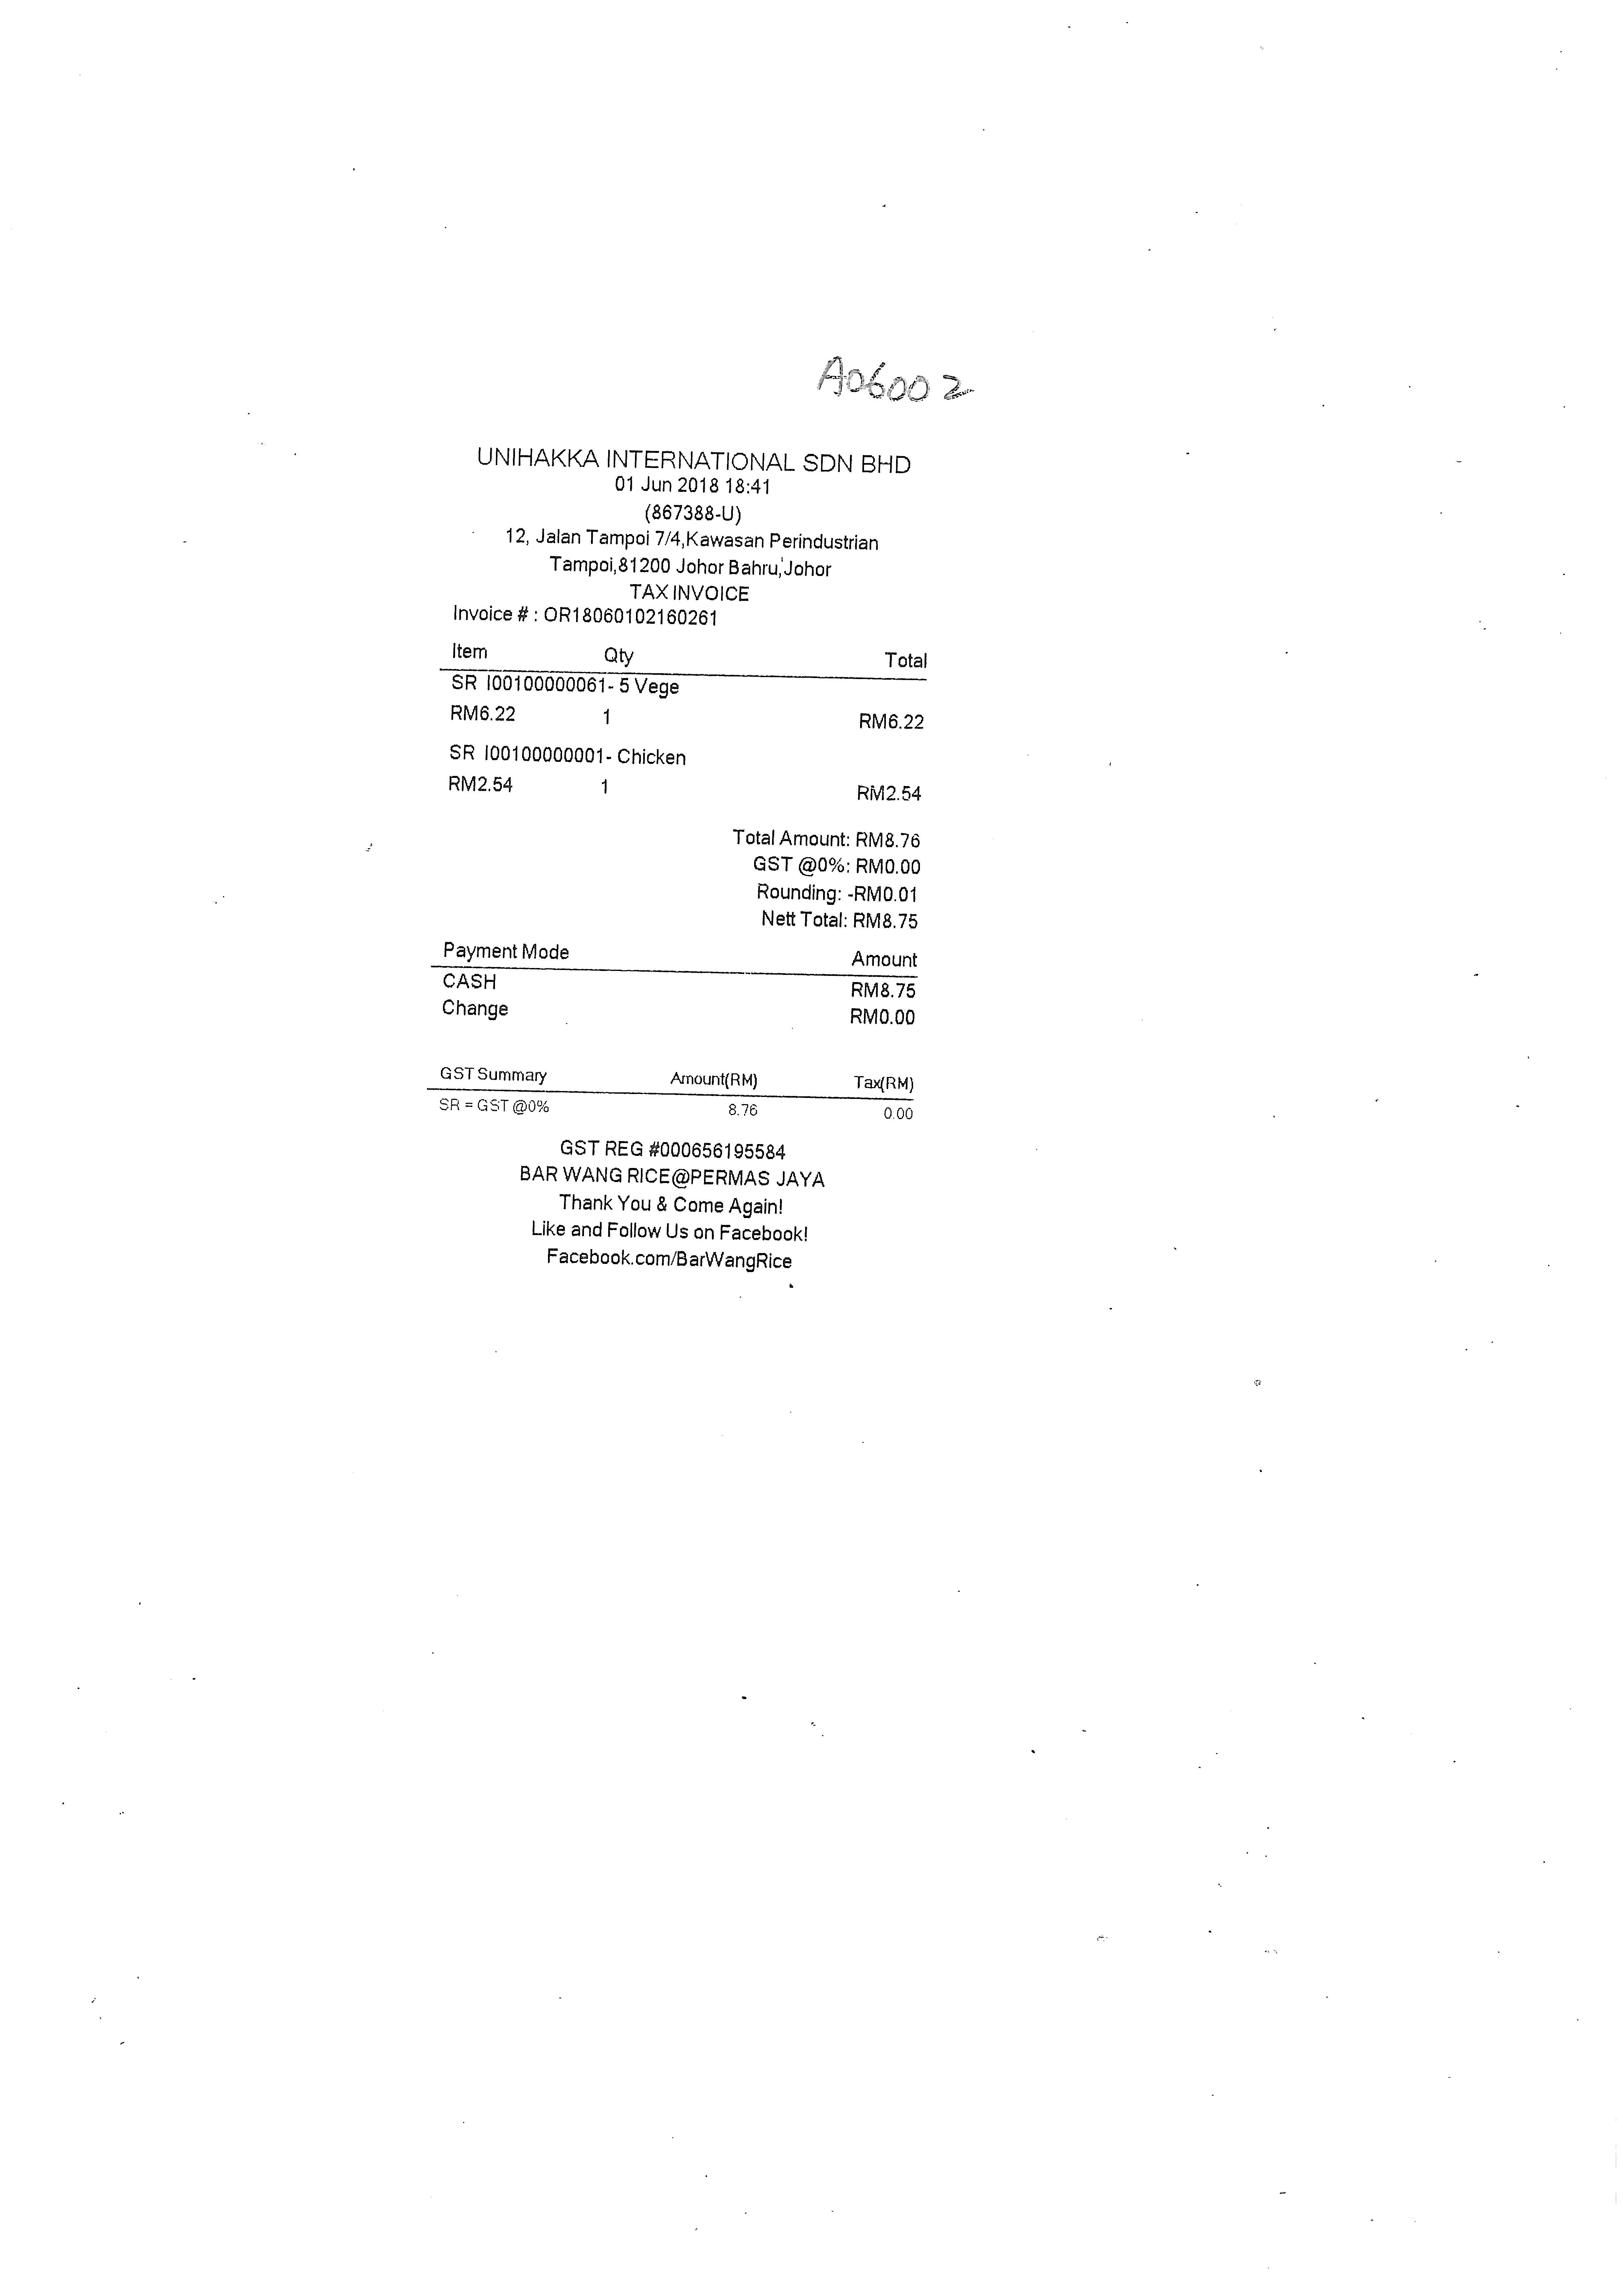

In [62]:
from IPython.display import Image, display
display(Image(filename=samples[97].path, width=512, height=512))

Typical errors:

* the image canno't be read, it gets stuck inside a thinking loop -> 1 times | this might require better image processing
* the images all have different sizes (which is fine), but some have 8k resolution which simply wastes processing time
* the accuracy already improves when using just lowercase, as the model often likes to writen in normal while the receipt shouts
* the accuracy goes up tremendously with just alphanumeric letter matching meaning most errors happen with wrongly placed signs and whitespaces

Improvements:

* I already did one preprocessing step, the total is orginally given as a string where a couple of times the currency is also given, but not often, so simply extracting the number already helps tremendously
* specifing in the prompt that the model should extract the EXACT text and not its own interpretation, summary or format
* downscale images above certain sizes as that won't really effect accuarcy
* cut out the large white scanning parts of images, and rotate them to be straight
* unify the lables to all have a matching fixed output

---

## Exercise 2 Fine-Tuning with LoRA: Shakespearean Translator

In this exercise, you will fine-tune a small language model using LoRA (Low-Rank Adaptation) to translate modern English conversations into Shakespearean English. The dataset consists of paired examples: standard English conversations and their Shakespearean translations.

Tasks:
1. Load and explore the provided dataset (modern English and Shakespearean translations).
2. Prepare the data for supervised fine-tuning (e.g., formatting input-output pairs).
3. Use the Qwen/Qwen3-1.7B model for LoRA fine-tuning.
4. Implement LoRA fine-tuning:
   • Configure LoRA parameters,
   • Train the model on the dataset,
   • Track training progress (e.g., loss).
5. Evaluate the fine-tuned model:
   • Generate translations for unseen modern English inputs,
   • Compare outputs to expected Shakespearean style.
6. Compare results before and after fine-tuning and discuss improvements.

Deliverables: A notebook including data preparation, training setup, fine-tuning process, example translations, and a qualitative comparison of results.

In [2]:
import torch
from datasets import Dataset
import transformers
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    BitsAndBytesConfig,
    GenerationConfig,
    pipeline
)
from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)
from trl import SFTTrainer, SFTConfig #, DataCollatorForCompletionOnlyLM

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
VRAM: 16.7 GB


In [4]:
class Shakespear(BaseModel):
    instruction: str
    input: str
    output: str
    
list_adapter = TypeAdapter(list[Shakespear])

In [5]:
shakespears_file = Path("/home/azureuser/localfiles/jonas_g/NLP4/EX09/data/shakespeare_dataset.json")
shakespears_data = list_adapter.validate_json(shakespears_file.read_text())

In [6]:
shakespears_data_dicts: list[dict[str, str]] = [data.model_dump() for data in shakespears_data]
dataset = Dataset.from_list(shakespears_data_dicts)
print(dataset)

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 400
})


In [7]:
model = "Qwen/Qwen3-1.7B"

In [8]:
tokenizer: transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer = AutoTokenizer.from_pretrained(model)

def format_chat(example):
    messages = [
        {"role": "system", "content": example["instruction"]},
        {"role": "user", "content": example["input"]},
        {"role": "assistant", "content": example["output"]},
    ]
    return {"messages":messages}
    # text = tokenizer.apply_chat_template(
    #     messages,
    #     tokenize=False,
    #     add_generation_prompt=False,
    #     enable_thinking=False
    # )
    # return {"text": text}

dataset = dataset.map(format_chat)
# print(dataset[0]["text"])
print(dataset[0])

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

{'instruction': 'Rewrite this conversation in Shakespearean English', 'input': 'A: *Hey! Long time no see. How’ve you been?*\nB: *Hey! Yeah, I’ve been good—just busy with work. How about you?*\nA: *Same here. Did you catch that new movie everyone’s talking about?*\nB: *Not yet, but I’m thinking about it this weekend. You going?*\nA: *Maybe! Let me know if you want to go together.*', 'output': 'A: *Hark! ’Tis long since last we met. How fares thee?*\nB: *Good morrow! Aye, well I fare—busy with mine labors. And thou?*\nA: *Even so. Hast thou beheld that new play of which all do speak?*\nB: *Nay, not yet, but perchance this sabbath I shall. Wilt thou attend?*\nA: *Mayhap! Send word if thou wouldst keep me company.*', 'messages': [{'role': 'system', 'content': 'Rewrite this conversation in Shakespearean English'}, {'role': 'user', 'content': 'A: *Hey! Long time no see. How’ve you been?*\nB: *Hey! Yeah, I’ve been good—just busy with work. How about you?*\nA: *Same here. Did you catch that n

In [9]:
base_model = AutoModelForCausalLM.from_pretrained(
    model,
    dtype=torch.float16,
    device_map="auto",
)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

In [10]:
for (name, _) in base_model.named_modules():
    print(name)


model
model.embed_tokens
model.layers
model.layers.0
model.layers.0.self_attn
model.layers.0.self_attn.q_proj
model.layers.0.self_attn.k_proj
model.layers.0.self_attn.v_proj
model.layers.0.self_attn.o_proj
model.layers.0.self_attn.q_norm
model.layers.0.self_attn.k_norm
model.layers.0.mlp
model.layers.0.mlp.gate_proj
model.layers.0.mlp.up_proj
model.layers.0.mlp.down_proj
model.layers.0.mlp.act_fn
model.layers.0.input_layernorm
model.layers.0.post_attention_layernorm
model.layers.1
model.layers.1.self_attn
model.layers.1.self_attn.q_proj
model.layers.1.self_attn.k_proj
model.layers.1.self_attn.v_proj
model.layers.1.self_attn.o_proj
model.layers.1.self_attn.q_norm
model.layers.1.self_attn.k_norm
model.layers.1.mlp
model.layers.1.mlp.gate_proj
model.layers.1.mlp.up_proj
model.layers.1.mlp.down_proj
model.layers.1.mlp.act_fn
model.layers.1.input_layernorm
model.layers.1.post_attention_layernorm
model.layers.2
model.layers.2.self_attn
model.layers.2.self_attn.q_proj
model.layers.2.self_att

In [11]:
pipe = pipeline("text-generation", model=base_model, tokenizer=tokenizer, clean_up_tokenization_spaces=False,return_full_text=False)

# 3. Apply the chat template and STRICTLY turn off thinking mode
def make_prompt(message: str):
    messages = [
            {"role": "system", "content": "Rewrite this conversation in Shakespearean English"},
            {"role": "user", "content": message}
        ]
    return tokenizer.apply_chat_template(
            conversation=messages, 
            tokenize=False, 
            add_generation_prompt=True,
            enable_thinking=False  # <-- This flag turns off thinking mode
        )

gen_config = GenerationConfig(
    max_new_tokens=512,
    do_sample=False,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id
)
outputs = pipe(make_prompt("Hi what is your name"), generation_config=gen_config, )
print(outputs[0]["generated_text"])#[len(prompt):])

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Hail, friend, and welcome to this discourse of words. I am but a nameless soul, a wanderer in the realm of speech. Let me be called, if thou wilt, by the name of Hamlet, or by some other appellation, as thou shalt choose. For in the vast expanse of the world, there are many voices, and each hath its own tongue. I am but a breath upon the wind, a whisper in the dark, and yet I speak. What shall I be called? Let me be known by thy own name, and let us part, if thou wilt.


In [12]:
message = """
A: *Morning! ☀️*
B: *Good morning! Did you sleep well?*
A: *Not bad—though my alarm went off at the worst time.*
B: *Haha, I feel that. Coffee yet?*
A: *Just made a fresh pot. Want some?*
B: *Absolutely!*
"""
outputs = pipe(make_prompt(message), generation_config=gen_config, )
print(outputs[0]["generated_text"])#[len(prompt):])

A: *Morning! ☀️*  
B: *Good morning! Did you sleep well?*  
A: *Not bad—though my alarm went off at the worst time.*  
B: *Haha, I feel that. Coffee yet?*  
A: *Just made a fresh pot. Want some?*  
B: *Absolutely!*


In [13]:
message = """
A: Ma name a bobe
B: What'cha talking aboot?
A: Ma name, buddy
B: Eh?
A: Ma name is bobe, now you get i't
B: Ah jeez sorry bobe
"""
outputs = pipe(make_prompt(message), generation_config=gen_config, )
print(outputs[0]["generated_text"])#[len(prompt):])

A: My name is Bobe  
B: What do you mean, thou art?  
A: My name is Bobe, now thou art it  
B: Ay, ay, I see, Bobe  
A: Ay, ay, I see, Bobe


In [ ]:
message = """
A: *Greetings! ☀️*
B: *Why hello jolly ol' chap!*
A: *A wonderfull day is it not?*
B: *Why yes of course mate!*
A: *Do you want to trink some tea?*
B: *Why, you know I'm allways down for a good cupa!*
"""
outputs = pipe(make_prompt(message), generation_config=gen_config, )
print(outputs[0]["generated_text"])#[len(prompt):])

A: *Greeting! ☀️*  
B: *Why hello jolly ol' chap!*  
A: *A wonderfull day is it not?*  
B: *Why yes of course mate!*  
A: *Do you want to trink some tea?*  
B: *Why, you know I'm allways down for a good cupa!*


In [15]:
lora_config = LoraConfig(
    r=8,                           # Rank: controls adapter size
    lora_alpha=16,                 # Scaling factor (2× rank is the standard heuristic)
    target_modules=[               # Which weight matrices to adapt
        "q_proj",
        "v_proj",
    ],
    lora_dropout=0.05,             # Light regularisation on LoRA layers
    bias="none",                   # Do not train bias terms
    task_type=TaskType.CAUSAL_LM,  # Causal language modeling
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable params: 1,605,632 || all params: 1,722,180,608 || trainable%: 0.0932


In [17]:
del base_model
import gc
gc.collect()

40

In [ ]:
# 1. Configure the trainer to calculate loss on completions only
training_args = SFTConfig(
    output_dir="./new_gwen",
    packing=True,
    assistant_only_loss=True,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,    # Effective batch size: 2 × 4 = 8
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=0.1,
    fp16=True,                         # Mixed precision — halves activation memory
    logging_steps=10,
    save_steps=100,
    save_total_limit=2,
    report_to="none",
)#type:ignore

In [19]:
trainer = SFTTrainer(
    model,
    train_dataset=dataset,
    args=training_args
)
trainer.train()

[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.
[RANK 0] You are using packing, but the attention implementation is not set to a supported flash attention variant. Packing gathers multiple samples into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernel

Tokenizing train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,3.136372
20,2.118962


TrainOutput(global_step=27, training_loss=2.436041584721318, metrics={'train_runtime': 172.105, 'train_samples_per_second': 1.22, 'train_steps_per_second': 0.157, 'total_flos': 1732010459074560.0, 'train_loss': 2.436041584721318})